# Homework Week 1 - Đại số tuyến tính cho AI

Họ tên: Nguyễn Huỳnh Nam Quốc, MSSV: 2453089

GitHub: namquoc2108-bot  

Em chọn dữ liệu dạng **Text**.

## Bài 1 - Biểu diễn dữ liệu thành ma trận và đo độ tương đồng

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
sentences = [
    "Hôm nay tui học Python thấy hơi khó nhưng cũng khá vui",
    "Mỗi ngày tui cố luyện code Python khoảng hai tiếng để tiến bộ hơn",
    "Tui thấy Python khá hữu ích khi xử lý dữ liệu cho bài tập trên lớp của tui",
    "Tui muốn học AI và machine learning để sau này làm được những dự án xịn xò",
    "Sáng nay trời mưa lớn làm tui kẹt xe và tới lớp trễ",
    "Chiều nay thời tiết mát mẻ nên tui thấy muốn ra ngoài đi dạo",
    "Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích",
    "Cầu thủ yêu thích tui ghi bàn trong trận bóng đá tối qua làm tui có nhiều cảm xúc thật bùng nổ"
]

print("Số câu:", len(sentences))
for i, s in enumerate(sentences, start=1):
    print(i, s)

Số câu: 8
1 Hôm nay tui học Python thấy hơi khó nhưng cũng khá vui
2 Mỗi ngày tui cố luyện code Python khoảng hai tiếng để tiến bộ hơn
3 Tui thấy Python khá hữu ích khi xử lý dữ liệu cho bài tập trên lớp của tui
4 Tui muốn học AI và machine learning để sau này làm được những dự án xịn xò
5 Sáng nay trời mưa lớn làm tui kẹt xe và tới lớp trễ
6 Chiều nay thời tiết mát mẻ nên tui thấy muốn ra ngoài đi dạo
7 Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích
8 Cầu thủ yêu thích tui ghi bàn trong trận bóng đá tối qua làm tui có nhiều cảm xúc thật bùng nổ


In [3]:
def tokenize(text):
    return re.findall(r"\w+", text.lower())

tokens_list = [tokenize(s) for s in sentences]

vocab = sorted(set(word for tokens in tokens_list for word in tokens))
word_to_idx = {word: i for i, word in enumerate(vocab)}

def to_vector(text):
    v = np.zeros(len(vocab))
    for word in tokenize(text):
        if word in word_to_idx:
            v[word_to_idx[word]] += 1
    return v

X = np.array([to_vector(s) for s in sentences])

print("Vocabulary:")
print(vocab)
print("X.shape =", X.shape)
print(X)

Vocabulary:
['ai', 'bài', 'bàn', 'bóng', 'bùng', 'bạn', 'bộ', 'chiều', 'cho', 'code', 'có', 'cùng', 'cũng', 'cảm', 'cầu', 'cố', 'của', 'dạo', 'dữ', 'dự', 'ghi', 'hai', 'hào', 'hôm', 'hơi', 'hơn', 'học', 'hứng', 'hữu', 'khi', 'khoảng', 'khá', 'khích', 'khó', 'kẹt', 'learning', 'liệu', 'luyện', 'làm', 'lý', 'lớn', 'lớp', 'machine', 'muốn', 'mát', 'mưa', 'mấy', 'mẻ', 'mỗi', 'nay', 'ngoài', 'ngày', 'nhiều', 'nhưng', 'những', 'này', 'nên', 'nổ', 'phấn', 'python', 'qua', 'ra', 'rất', 'sau', 'sáng', 'thích', 'thấy', 'thật', 'thời', 'thủ', 'tiến', 'tiếng', 'tiết', 'trong', 'trên', 'trận', 'trễ', 'trời', 'tui', 'tập', 'tối', 'tới', 'vui', 'và', 'xe', 'xem', 'xò', 'xúc', 'xịn', 'xử', 'yêu', 'án', 'ích', 'đi', 'đá', 'được', 'để', 'đứa']
X.shape = (8, 98)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0

### Giải thích ma trận X

Ở bước này, em biến 8 câu văn bình thường thành một ma trận số để máy tính có thể xử lý được. Ban đầu các câu chỉ là chữ, nhưng sau khi tách từ và gom tất cả từ khác nhau vào `vocab`, mỗi câu được biểu diễn lại bằng một vector đếm từ.

Trong bài của em, `X.shape = (8, 98)`. Em hiểu kết quả này như sau:

- Số `8` là số câu em đưa vào trong danh sách `sentences`.
- Số `98` là số từ khác nhau xuất hiện sau khi tách từ.
- Mỗi hàng trong `X` tương ứng với một câu.
- Mỗi cột tương ứng với một từ trong vocabulary.
- Giá trị trong ma trận cho biết từ đó xuất hiện bao nhiêu lần trong câu đó.

Ví dụ, các câu 1, 2, 3 đều có từ `python`, nên ở cột tương ứng với `python`, những câu này sẽ có giá trị khác 0. Ngược lại, câu nói về bóng đá thì gần như không có các từ như `python`, `code`, `dữ liệu`, nên những cột đó bằng 0.

Điều em thấy quan trọng ở đây là máy không đọc câu giống con người. Nó không cảm nhận được câu nào “nghe giống nhau”, mà chỉ nhìn xem các câu có dùng chung từ hay không. Vì vậy Bag-of-Words khá dễ hiểu, nhưng cũng có hạn chế là nó chưa hiểu được ngữ nghĩa sâu của câu.


In [4]:
mean_col = X.mean(axis=0)

print("Shape của X:", X.shape)
print("Shape của mean_col:", mean_col.shape)

X_centered = X - mean_col

print("Shape sau khi trừ mean:", X_centered.shape)
print(X_centered)

Shape của X: (8, 98)
Shape của mean_col: (98,)
Shape sau khi trừ mean: (8, 98)
[[-0.125 -0.125 -0.125 -0.25  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.125  0.875 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.125 -0.125  0.875  0.875 -0.125  0.75  -0.125 -0.125 -0.125
  -0.125  0.75  -0.125  0.875 -0.125 -0.125 -0.125 -0.125 -0.375 -0.125
  -0.125 -0.25  -0.125 -0.25  -0.125 -0.125 -0.125 -0.125 -0.125  0.625
  -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.125 -0.125 -0.125  0.625
  -0.25  -0.125 -0.125 -0.125 -0.125 -0.125  0.625 -0.125 -0.125 -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.25  -0.125
  -0.25  -0.125  0.875 -0.375 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.125 -0.125 -0.125 -0.25  -0.125 -0.25  -0.125]
 [-0.125 -0.125 -0.125 -0.25  -0.125 -0.125  0.875 -0.125 -0.125  0.875
  -0.125 -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.125 -0.125
  -0.125  0.875 -0.125 -0.125 -0.125  0.875 -0.25  -0.125 -0.125 -0.12

### Giải thích broadcasting

Sau khi có ma trận `X`, em tính `mean_col = X.mean(axis=0)` để lấy trung bình theo từng cột. Nói đơn giản hơn, em đang xem mỗi từ trong vocabulary xuất hiện trung bình bao nhiêu lần trên toàn bộ 8 câu.

Kết quả shape cho thấy:

- `X` có shape `(8, 98)`, tức là 8 câu và 98 từ.
- `mean_col` có shape `(98,)`, tức là mỗi từ có một giá trị trung bình riêng.
- Khi tính `X - mean_col`, NumPy tự hiểu là lấy vector trung bình này trừ cho từng hàng của `X`.

Lúc đầu nhìn phép trừ này có vẻ hơi lạ, vì một bên là ma trận 8 hàng, một bên chỉ là một vector. Nhưng đây chính là broadcasting: NumPy “trải” `mean_col` xuống 8 hàng để trừ theo từng cột tương ứng.

Sau khi trừ trung bình, shape vẫn là `(8, 98)` vì số câu và số từ không thay đổi. Chỉ có giá trị bên trong ma trận thay đổi: dữ liệu được đưa về quanh mức trung bình hơn. Bước này giúp dữ liệu phù hợp hơn khi làm SVD/PCA, vì lúc đó mình quan tâm đến sự khác nhau giữa các câu so với mặt bằng chung.


In [5]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    
    X_norm = np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)
    
    X_norm = np.where(X_norm == 0, 1, X_norm)
    Y_norm = np.where(Y_norm == 0, 1, Y_norm)
    
    Xn = X / X_norm
    Yn = Y / Y_norm
    
    return Xn @ Yn.T

sim_matrix = cosine_similarity(X)

print("Cosine similarity matrix:")
print(np.round(sim_matrix, 3))

Cosine similarity matrix:
[[1.    0.154 0.323 0.14  0.16  0.231 0.072 0.118]
 [0.154 1.    0.179 0.13  0.074 0.071 0.067 0.109]
 [0.323 0.179 1.    0.108 0.186 0.179 0.112 0.183]
 [0.14  0.13  0.108 1.    0.202 0.13  0.121 0.149]
 [0.16  0.074 0.186 0.202 1.    0.148 0.139 0.17 ]
 [0.231 0.071 0.179 0.13  0.148 1.    0.067 0.109]
 [0.072 0.067 0.112 0.121 0.139 0.067 1.    0.306]
 [0.118 0.109 0.183 0.149 0.17  0.109 0.306 1.   ]]


### Giải thích ma trận cosine similarity

Ma trận cosine similarity có kích thước `8 x 8` vì em đang so sánh từng câu với toàn bộ 8 câu còn lại, kể cả chính nó.

Điều dễ thấy nhất là đường chéo chính đều bằng `1.0`. Lý do là một câu khi đem so với chính nó thì vector giống hoàn toàn, nên góc giữa hai vector bằng 0 và cosine bằng 1.

Các giá trị ngoài đường chéo nhỏ hơn nhiều. Điều này khá hợp lý vì bộ câu của em có nhiều chủ đề khác nhau: học Python/AI, thời tiết và bóng đá. Hai câu càng dùng nhiều từ chung thì cosine càng cao. Hai câu càng ít từ chung thì cosine càng thấp.

Tuy nhiên, em thấy phần này cũng cho thấy một điểm yếu khá rõ của Bag-of-Words. Có những câu con người đọc vào thấy cùng chủ đề, nhưng nếu chúng dùng từ khác nhau thì điểm cosine vẫn không cao. Ngược lại, có những câu khác chủ đề nhưng lại trùng các từ rất chung như `tui`, `nay`, `và`, `có`, thì điểm cosine có thể bị kéo lên một chút.

Vì vậy, khi nhìn ma trận này, em không chỉ nhìn điểm số cao hay thấp, mà còn phải xem lại hai câu đó thật sự trùng những từ nào.


In [6]:
def search(query, top_k=3):
    q_vec = to_vector(query).reshape(1, -1)
    sims = cosine_similarity(q_vec, X).flatten()
    
    top_indices = np.argsort(sims)[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            "index": idx,
            "sentence": sentences[idx],
            "score": float(sims[idx])
        })
    
    return results

results = search("AI và Machine Learning áp dụng được gì trong công việc?", top_k=3)

for r in results:
    print(f"Câu {r['index'] + 1}: {r['sentence']}")
    print("Gtri của cosine:", round(r["score"], 3))
    print()

Câu 4: Tui muốn học AI và machine learning để sau này làm được những dự án xịn xò
Gtri của cosine: 0.495

Câu 5: Sáng nay trời mưa lớn làm tui kẹt xe và tới lớp trễ
Gtri của cosine: 0.113

Câu 7: Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích
Gtri của cosine: 0.102



In [7]:
query = "AI và Machine Learning áp dụng được gì trong công việc?"
query_tokens = tokenize(query)
kept_tokens = [w for w in query_tokens if w in word_to_idx]

print("Các từ trong query sau khi tách:", query_tokens)
print("Các từ của query có trong vocabulary:", kept_tokens)
print()

for r in results:
    idx = r["index"]
    sent_tokens = tokenize(sentences[idx])
    common_words = sorted(set(kept_tokens) & set(sent_tokens))
    print(f"Câu {idx + 1}: {sentences[idx]}")
    print("Từ chung với query:", common_words)
    print("Cosine:", round(r["score"], 3))
    print()

Các từ trong query sau khi tách: ['ai', 'và', 'machine', 'learning', 'áp', 'dụng', 'được', 'gì', 'trong', 'công', 'việc']
Các từ của query có trong vocabulary: ['ai', 'và', 'machine', 'learning', 'được', 'trong']

Câu 4: Tui muốn học AI và machine learning để sau này làm được những dự án xịn xò
Từ chung với query: ['ai', 'learning', 'machine', 'và', 'được']
Cosine: 0.495

Câu 5: Sáng nay trời mưa lớn làm tui kẹt xe và tới lớp trễ
Từ chung với query: ['và']
Cosine: 0.113

Câu 7: Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích
Từ chung với query: ['và']
Cosine: 0.102



### Giải thích kết quả search

Với query `"AI và Machine Learning áp dụng được gì trong công việc?"`, kết quả cao nhất là **câu 4** với cosine khoảng `0.495`.

Em thấy kết quả này khá hợp lý, vì câu 4 là:

`"Tui muốn học AI và machine learning để sau này làm được những dự án xịn xò"`

Câu này trùng trực tiếp với query ở nhiều từ quan trọng như `ai`, `machine`, `learning`, `và`, `được`. Trong cách biểu diễn Bag-of-Words, những từ trùng nhau này làm cho dot product giữa query và câu 4 lớn hơn, nên điểm cosine cũng cao hơn.

Một điều đáng chú ý là không phải toàn bộ query đều được dùng. Những từ như `áp`, `dụng`, `công`, `việc` không có trong vocabulary ban đầu, nên khi chuyển query thành vector thì chúng gần như bị bỏ qua. Nói cách khác, chương trình chỉ hiểu những từ mà nó đã từng thấy trong 8 câu ban đầu.

Một vài câu khác vẫn lọt vào top 3 dù không thật sự sát nghĩa bằng câu 4. Lý do là chúng có thể trùng một số từ rất phổ biến như `và`, `tui`, hoặc `làm`. Đây là lý do kết quả tìm kiếm đôi khi hơi nhiễu. Nếu muốn kết quả tốt hơn, mình có thể bỏ stopwords hoặc dùng embedding, nhưng trong phạm vi bài này em giữ cách làm đơn giản bằng NumPy để đúng yêu cầu của đề.


In [8]:
S = cosine_similarity(X)

S_max = S.copy()
np.fill_diagonal(S_max, -np.inf)

most_similar = np.unravel_index(np.argmax(S_max), S_max.shape)

S_min = S.copy()
np.fill_diagonal(S_min, np.inf)

least_similar = np.unravel_index(np.argmin(S_min), S_min.shape)

print("Cặp giống nhau nhất:")
print(most_similar[0] + 1, sentences[most_similar[0]])
print(most_similar[1] + 1, sentences[most_similar[1]])
print("Cosine:", round(S[most_similar], 3))

print("\nCặp khác biệt nhất:")
print(least_similar[0] + 1, sentences[least_similar[0]])
print(least_similar[1] + 1, sentences[least_similar[1]])
print("Cosine:", round(S[least_similar], 3))

Cặp giống nhau nhất:
1 Hôm nay tui học Python thấy hơi khó nhưng cũng khá vui
3 Tui thấy Python khá hữu ích khi xử lý dữ liệu cho bài tập trên lớp của tui
Cosine: 0.323

Cặp khác biệt nhất:
2 Mỗi ngày tui cố luyện code Python khoảng hai tiếng để tiến bộ hơn
7 Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích
Cosine: 0.067


In [9]:
def explain_pair_by_words(i, j):
    words_i = tokenize(sentences[i])
    words_j = tokenize(sentences[j])
    common_words = sorted(set(words_i) & set(words_j))

    dot_value = float(X[i] @ X[j])
    norm_i = float(np.linalg.norm(X[i]))
    norm_j = float(np.linalg.norm(X[j]))
    cosine_value = dot_value / (norm_i * norm_j)

    print(f"So sánh câu {i + 1} và câu {j + 1}")
    print("Câu", i + 1, ":", sentences[i])
    print("Câu", j + 1, ":", sentences[j])
    print("Từ chung:", common_words)
    print("Dot product:", dot_value)
    print("Norm câu", i + 1, ":", round(norm_i, 3))
    print("Norm câu", j + 1, ":", round(norm_j, 3))
    print("Cosine:", round(cosine_value, 3))
    print("-" * 80)

explain_pair_by_words(most_similar[0], most_similar[1])
explain_pair_by_words(least_similar[0], least_similar[1])
explain_pair_by_words(6, 7)  # câu 7 và 8, cùng chủ đề bóng đá

So sánh câu 1 và câu 3
Câu 1 : Hôm nay tui học Python thấy hơi khó nhưng cũng khá vui
Câu 3 : Tui thấy Python khá hữu ích khi xử lý dữ liệu cho bài tập trên lớp của tui
Từ chung: ['khá', 'python', 'thấy', 'tui']
Dot product: 5.0
Norm câu 1 : 3.464
Norm câu 3 : 4.472
Cosine: 0.323
--------------------------------------------------------------------------------
So sánh câu 2 và câu 7
Câu 2 : Mỗi ngày tui cố luyện code Python khoảng hai tiếng để tiến bộ hơn
Câu 7 : Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích
Từ chung: ['tui']
Dot product: 1.0
Norm câu 2 : 3.742
Norm câu 7 : 4.0
Cosine: 0.067
--------------------------------------------------------------------------------
So sánh câu 7 và câu 8
Câu 7 : Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích
Câu 8 : Cầu thủ yêu thích tui ghi bàn trong trận bóng đá tối qua làm tui có nhiều cảm xúc thật bùng nổ
Từ chung: ['bóng', 'qua', 'tui', 'tối', 'đá']
Dot product: 6.0
Norm câu 7 : 4.0
Norm câu 8 : 4.

### Nhận xét chi tiết về cặp giống và khác nhau nhất

Kết quả làm em hơi bất ngờ lúc đầu, vì cặp giống nhau nhất không phải lúc nào cũng là hai câu mà mình cảm thấy cùng chủ đề nhất theo nghĩa tự nhiên. Theo kết quả chạy được, cặp giống nhau nhất là **câu 1 và câu 3**, với cosine khoảng `0.323`.

- Câu 1: `"Hôm nay tui học Python thấy hơi khó nhưng cũng khá vui"`
- Câu 3: `"Tui thấy Python khá hữu ích khi xử lý dữ liệu cho bài tập trên lớp của tui"`

Nếu đọc bằng cảm giác con người, hai câu này đều liên quan đến việc học Python nên cũng khá gần nhau. Khi kiểm tra theo Bag-of-Words, hai câu có một số từ trùng như `python`, `thấy`, `khá`, `tui`. Đặc biệt, câu 3 có từ `tui` xuất hiện nhiều hơn một lần, nên từ này đóng góp mạnh hơn vào dot product. Vì vậy vector của hai câu này có hướng gần nhau hơn các cặp khác, làm cosine cao nhất.

Cặp khác biệt nhất là **câu 2 và câu 7**, với cosine khoảng `0.067`.

- Câu 2 nói về việc luyện code Python mỗi ngày.
- Câu 7 nói về xem bóng đá với bạn bè.

Hai câu này gần như không có từ quan trọng nào giống nhau. Một bên có các từ như `code`, `python`, `tiến`, `bộ`; bên kia có `bóng`, `đá`, `bạn`, `hào`, `hứng`. Vì ít giao nhau như vậy nên dot product rất nhỏ, dẫn đến cosine thấp nhất. Kết quả này nhìn chung đúng với trực giác, vì hai câu thuộc hai bối cảnh khá xa nhau.

Một điểm em thấy thú vị là **câu 7 và câu 8** đều nói về bóng đá, và điểm cosine của cặp này cũng khá cao, khoảng `0.306`. Hai câu có nhiều từ chung như `bóng`, `đá`, `tối`, `qua`, `tui`. Điều này cho thấy Bag-of-Words vẫn bắt được sự giống nhau nếu hai câu cùng chủ đề và có dùng chung từ khóa rõ ràng.

Từ phần này, em rút ra là kết quả cosine không chỉ phụ thuộc vào “ý nghĩa” theo cách con người hiểu, mà phụ thuộc rất mạnh vào các từ xuất hiện trùng nhau. Vì vậy khi giải thích kết quả, em cần nhìn lại cả điểm cosine lẫn danh sách từ chung giữa hai câu.


## Bài 2 - Giảm chiều dữ liệu text bằng SVD

In [10]:
Xc = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

coords = U[:, :2] * S[:2]

print("Shape của U:", U.shape)
print("Shape của S:", S.shape)
print("Shape của Vt:", Vt.shape)
print("Shape của coords:", coords.shape)

print(coords)

Shape của U: (8, 8)
Shape của S: (8,)
Shape của Vt: (8, 98)
Shape của coords: (8, 2)
[[-1.16026388 -0.48640847]
 [-0.84091719  0.22055138]
 [-1.42366437 -2.82292538]
 [-0.44362375  2.6348368 ]
 [-0.33648756  0.66867949]
 [-1.02516287  0.26718816]
 [ 1.61370155  0.49291737]
 [ 3.61641807 -0.97483935]]


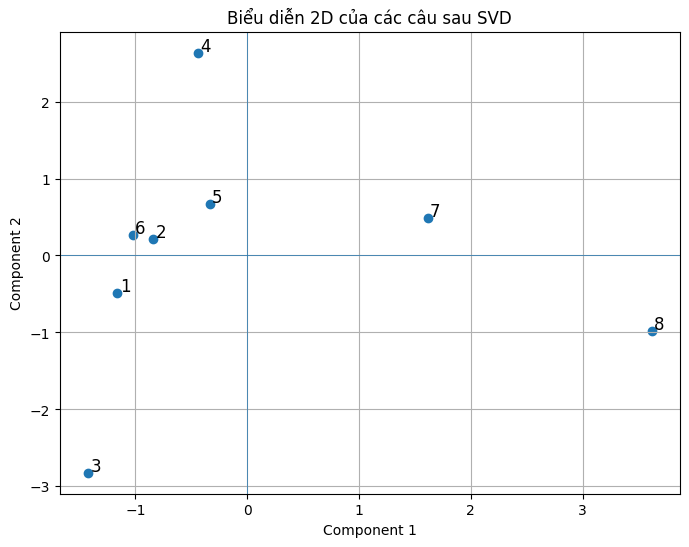

1: Hôm nay tui học Python thấy hơi khó nhưng cũng khá vui
2: Mỗi ngày tui cố luyện code Python khoảng hai tiếng để tiến bộ hơn
3: Tui thấy Python khá hữu ích khi xử lý dữ liệu cho bài tập trên lớp của tui
4: Tui muốn học AI và machine learning để sau này làm được những dự án xịn xò
5: Sáng nay trời mưa lớn làm tui kẹt xe và tới lớp trễ
6: Chiều nay thời tiết mát mẻ nên tui thấy muốn ra ngoài đi dạo
7: Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích
8: Cầu thủ yêu thích tui ghi bàn trong trận bóng đá tối qua làm tui có nhiều cảm xúc thật bùng nổ


In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(coords[:, 0], coords[:, 1])

for i, (x, y) in enumerate(coords):
    plt.text(x + 0.02, y + 0.02, str(i + 1), fontsize=12)

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Biểu diễn 2D của các câu sau SVD")
plt.grid(True)
plt.show()

for i, s in enumerate(sentences, start=1):
    print(f"{i}: {s}")

### Nhận xét chi tiết về kết quả SVD và biểu đồ 2D

Sau khi center dữ liệu và dùng SVD, mỗi câu ban đầu từ không gian 98 chiều được đưa về 2 chiều bằng công thức:

`coords = U[:, :2] * S[:2]`

Kết quả `coords.shape = (8, 2)` nghĩa là mỗi câu bây giờ chỉ còn 2 tọa độ, nên em có thể vẽ chúng lên mặt phẳng 2D để quan sát trực quan hơn.

Khi nhìn biểu đồ, em hiểu nó theo cách sau: các câu nằm gần nhau thường là các câu có cách dùng từ tương đối giống nhau. Còn các câu nằm xa nhau thì thường khác nhau nhiều về từ vựng hoặc chủ đề.

Một vài quan sát cụ thể:

- **Câu 1 và câu 3** nằm tương đối gần nhau. Điều này khớp với kết quả cosine ở Bài 1, vì hai câu đều có các từ như `python`, `tui`, `thấy`, `khá` và cùng xoay quanh chuyện học Python.
- **Câu 5 và câu 6** cũng có xu hướng gần nhau hơn so với nhiều câu khác, vì cả hai đều có bối cảnh thời tiết/ngày hôm nay. Một câu nói về trời mưa và đi học trễ, câu còn lại nói về thời tiết mát mẻ và đi dạo.
- **Câu 7 và câu 8** nằm khá gần về mặt chủ đề bóng đá. Hai câu cùng có các từ như `bóng`, `đá`, `tối`, `qua`, `tui`, nên khi giảm chiều chúng vẫn giữ được sự liên quan nhất định.
- **Câu 3 và câu 4** đều liên quan đến học tập/công nghệ, nhưng không nằm quá sát nhau. Lý do là câu 3 dùng nhiều từ về `python`, `dữ liệu`, `bài tập`, còn câu 4 lại dùng `ai`, `machine`, `learning`, `dự án`. Con người đọc thì thấy hai câu có liên quan, nhưng Bag-of-Words chỉ thấy chúng không trùng quá nhiều từ.

Điều em rút ra là SVD giúp mình nhìn dữ liệu dễ hơn, nhưng kết quả vẫn phụ thuộc vào cách biểu diễn ban đầu. Vì dữ liệu ban đầu là Bag-of-Words nên biểu đồ 2D phản ánh sự giống nhau về mặt từ vựng nhiều hơn là sự giống nhau sâu về ý nghĩa.

Em liên hệ phần này với PCA/eigen như sau: SVD tìm ra những hướng quan trọng nhất trong dữ liệu, rồi giữ lại hai hướng đầu tiên để vẽ. Nói một cách dễ hiểu, thay vì nhìn dữ liệu trong 98 chiều rất khó tưởng tượng, em nén nó xuống 2 chiều để xem các câu đang tụ lại hoặc tách xa nhau như thế nào.


In [12]:
labels = np.array([
    "AI",
    "AI",
    "AI",
    "AI",
    "Weather",
    "Weather",
    "Sports",
    "Sports"
])

def classify_1nn(query):
    q_vec = to_vector(query).reshape(1, -1)
    sims = cosine_similarity(q_vec, X).flatten()
    best_idx = np.argmax(sims)
    
    return {
        "query": query,
        "predicted_label": str(labels[best_idx]),
        "nearest_sentence": sentences[best_idx],
        "score": float(sims[best_idx])
    }

test_queries = [
    "AI cần dữ liệu để học",
    "ngày mai trời có mưa",
    "đội bóng đá thi đấu"
]

for q in test_queries:
    result = classify_1nn(q)
    print(result)

{'query': 'AI cần dữ liệu để học', 'predicted_label': 'AI', 'nearest_sentence': 'Tui muốn học AI và machine learning để sau này làm được những dự án xịn xò', 'score': 0.32539568672798425}
{'query': 'ngày mai trời có mưa', 'predicted_label': 'Weather', 'nearest_sentence': 'Sáng nay trời mưa lớn làm tui kẹt xe và tới lớp trễ', 'score': 0.2773500981126146}
{'query': 'đội bóng đá thi đấu', 'predicted_label': 'Sports', 'nearest_sentence': 'Tối qua tui xem bóng đá cùng mấy đứa bạn và rất hào hứng, phấn khích', 'score': 0.35355339059327373}


### Nhận xét phần bonus 1-NN bằng cosine

Ở phần bonus, em dùng ý tưởng 1-NN theo cách khá trực quan: khi có một câu query mới, em chuyển câu đó thành vector Bag-of-Words, rồi đem so sánh cosine với 8 câu ban đầu. Câu nào gần query nhất thì em lấy nhãn của câu đó làm nhãn dự đoán.

Kết quả chạy được khá hợp lý:

- Query `"AI cần dữ liệu để học"` được dự đoán là `AI`, vì query có các từ liên quan đến nhóm học/AI như `ai`, `học`, `dữ liệu`.
- Query `"ngày mai trời có mưa"` được dự đoán là `Weather`, vì nó có các từ như `trời`, `mưa`, gần với câu thời tiết trong dữ liệu.
- Query `"đội bóng đá thi đấu"` được dự đoán là `Sports`, vì có từ `bóng`, `đá`, gần với hai câu về bóng đá.

Em thấy cách này dễ hiểu vì nó giống như hỏi: “Trong 8 câu đã biết, câu nào giống câu mới nhất?”. Nếu câu giống nhất thuộc nhóm Sports thì query cũng được gán Sports.

Tuy nhiên, cách này vẫn có điểm yếu. Nếu query dùng những từ chưa có trong vocabulary, chương trình sẽ không hiểu các từ đó. Ví dụ nếu nói `trí tuệ nhân tạo` thay vì `AI`, hoặc `túc cầu` thay vì `bóng đá`, mô hình có thể không nhận ra hai cách nói này gần nghĩa với nhau. Vì vậy 1-NN bằng Bag-of-Words phù hợp để minh họa ý tưởng cosine, nhưng chưa phải là cách hiểu ngôn ngữ tốt như các mô hình embedding hiện đại.
